# Overview {#sec-conceptnet}

To see whether people are adapting learned gestures depending on how (in)accurate they were in understanding the meaning of the gestures, we will look at the degree of misunderstanding.

We operationalize degree of misunderstanding as a conceptual similarity between target concept and answer offered by a guesser. 

To have a reproducible measure of conceptual similarity, we use the ConceptNet [@speer_etal18] to extract embeddings for concepts used in our study, and calculate cosine similarity between the target concept and guessed answer. 

In [58]:
#| code-fold: true
#| code-summary: Code to load packages and prepare environment

import numpy as np
import os
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

curfolder = os.getcwd()
answerfile = os.path.join(curfolder, 'exp_id_log.csv')

answerdf = pd.read_csv(answerfile, sep=',', header=0)
answerdf.head(10)

# get rid of the first row - this is lab stimuli
answerdf = answerdf.iloc[1:]
answerdf = answerdf.reset_index(drop=True)

First, we need to prepare the dataframe for easy data manipulation. 


In [45]:
answerdf.head(10)

,language,group,order_present,answers,order_prod,modality,chain,generation,training_time,testing_time,participant_id
0,de,n,"['kalt', 'Donner', 'rennen', 'langsam', 'leise']","['kalt', 'Vogel', 'rennen', 'slowmotion', 'lei...","['Donner', 'kalt', 'langsam', 'leise', 'rennen']",gesture,1,1,176.531814,248.789733,1.0
1,de,n,"['kalt', 'leise', 'Donner', 'langsam', 'rennen']","['kalt', 'leise', 'Explosion', 'gehen', 'schne...","['langsam', 'leise', 'Donner', 'kalt', 'rennen']",gesture,1,2,202.260491,279.110402,2.0
2,de,n,"['langsam', 'leise', 'kalt', 'rennen', 'Donner']","['gehen', 'Ruhe', 'kalt', 'schnell', 'Explosion']","['rennen', 'langsam', 'leise', 'Donner', 'kalt']",gesture,1,3,212.516623,275.318227,3.0
3,de,n,"['leise', 'Donner', 'kalt', 'rennen', 'langsam']","['Ruhe', 'Regen', 'kalt', 'laufen', 'gehen']","['rennen', 'leise', 'langsam', 'kalt', 'Donner']",gesture,1,4,166.291701,240.197646,4.0
4,de,n,"['Donner', 'kalt', 'rennen', 'leise', 'langsam']","['Explosion', 'kalt', 'joggen', 'leise', 'skif...","['kalt', 'leise', 'rennen', 'Donner', 'langsam']",gesture,1,5,213.156721,303.383002,5.0
5,en,n,"['silent', 'slow', 'thunderstorm', 'to run', '...","['quiet', 'walking', 'explosion', 'fast', 'cold']","['cold', 'slow', 'silent', 'to run', 'thunders...",gesture,1,6,241.685480,328.871579,6.0
6,en,n,"['to run', 'silent', 'thunderstorm', 'cold', '...","['coming', 'silence', 'rain', 'cold', 'walking']","['slow', 'cold', 'to run', 'thunderstorm', 'si...",gesture,1,7,222.468755,304.470788,7.0
7,de,n,"['rennen', 'kalt', 'Donner', 'langsam', 'leise']","['gehen', 'kalt', 'regnen', 'gehen', 'leise']","['rennen', 'leise', 'kalt', 'langsam', 'Donner']",gesture,1,8,222.356796,309.414939,8.0
8,de,n,"['Donner', 'rennen', 'langsam', 'kalt', 'leise']","['Regen', 'marschieren', 'gehen', 'kalt', 'lei...","['leise', 'rennen', 'kalt', 'Donner', 'langsam']",gesture,1,9,216.612760,297.447207,9.0
9,en,n,"['slow', 'silent', 'to run', 'thunderstorm', '...","['walking', 'silence', 'run', 'rain', 'cold']","['thunderstorm', 'to run', 'cold', 'slow', 'si...",gesture,1,10,218.068834,289.078622,10.0


In [59]:
# create empty df with columns concept, answer, chain, generation
df = pd.DataFrame(columns=['concept', 'answer', 'chain', 'generation'])

# loop over rows of answerdf
for index, row in answerdf.iterrows():

    # get chain and generation
    chain = row['chain']
    generation = row['generation']
    language = row['language']

    # get list of order_prod
    concepts = row['order_present'].split(',')
    # get rid of [], ' and "´
    concepts = [concept.strip("[] '") for concept in concepts]

    # get list of answers
    answers = row['answers'].split(',')
    answers = [answer.strip("[] '") for answer in answers]


    # loop over concepts and answers
    for concept, answer in zip(concepts, answers):
        # create new row
        new_row = pd.DataFrame({'concept': [concept], 'answer': [answer], 'chain': [chain], 'generation': [generation], 'language': [language]})
        # append new row to df
        df = pd.concat([df, new_row], ignore_index=True)

# make sure nowhere is empty space
df['concept'] = df['concept'].str.strip()
df['answer'] = df['answer'].str.strip()
df.head(10)

,concept,answer,chain,generation,language
0,kalt,kalt,1,1,de
1,Donner,Vogel,1,1,de
2,rennen,rennen,1,1,de
3,langsam,slowmotion,1,1,de
4,leise,leise,1,1,de
5,kalt,kalt,1,2,de
6,leise,leise,1,2,de
7,Donner,Explosion,1,2,de
8,langsam,gehen,1,2,de
9,rennen,schnell,1,2,de


In [60]:
# some corrections
df.loc[df['answer'] == 'kält', 'answer'] = 'kälte'
df.loc[df['answer'] == 'källte', 'answer'] = 'kälte'
df.loc[df['answer'] == 'balwerfen', 'answer'] = 'ballwerfen'
df.loc[df['answer'] == 'Balwerfen', 'answer'] = 'ballwerfen'
df.loc[df['answer'] == 'lshiftkälte', 'answer'] = 'kälte'

In [61]:
# to run is run
df.loc[df['answer'] == 'to run', 'answer'] = 'run'
df.loc[df['concept'] == 'to run', 'concept'] = 'run'

# Calculating cosine similarity

Now we will load in [ConceptNet numberbatch (version 19.08)](https://github.com/commonsense/conceptnet-numberbatch) and compute cosine similarity for each pair


In [32]:
#| code-fold: true
#| code-summary: Custom functions

# Load embeddings from a file
def load_embeddings(file_path):
    embeddings = {}
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.array(values[1:], dtype='float32')
            embeddings[word] = vector
    return embeddings

# Cosine similarity
def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    return dot_product / (norm_vec1 * norm_vec2)

We will use multilingual numberbatch to extract words in the original language of experiment - English and German


In [33]:
# load embeddings
embeddings = load_embeddings('numberbatch\\numberbatch.txt')

This is how a single concept is represented (here skiën, engl. skiing)

In [36]:
#| echo: false

vec_de = embeddings.get('/c/de/donner')
print(vec_de)

[-0.0218 -0.0808  0.1459  0.0069 -0.034  -0.1064  0.006   0.1157 -0.0402
  0.2344  0.1786 -0.0543 -0.0828  0.0041  0.0859 -0.0699 -0.0283  0.0038
 -0.1345  0.091  -0.0957 -0.0041  0.0589 -0.0893  0.0443 -0.0437 -0.1105
 -0.0773  0.0693  0.0157  0.0589 -0.0542  0.0913 -0.0306 -0.0072  0.0285
 -0.0675 -0.0385  0.114  -0.0028 -0.1058 -0.0272 -0.1335  0.041  -0.0201
 -0.0345 -0.0653  0.1318 -0.0368 -0.0258 -0.0149  0.0005  0.0257 -0.0477
  0.0367  0.0113  0.0933  0.0646 -0.0476 -0.1068 -0.0192 -0.0045 -0.0613
  0.0502  0.0498 -0.0121  0.0275  0.0741 -0.1829  0.0739 -0.0388  0.049
  0.0504 -0.0172 -0.0505 -0.0321 -0.0744  0.0091 -0.0162  0.0227  0.0202
 -0.0233  0.0356  0.0248  0.0413  0.077  -0.038   0.0141  0.0106  0.0045
  0.0397  0.0078  0.0561 -0.0141  0.0796  0.0372 -0.0946 -0.0318  0.0267
  0.0192  0.0573 -0.0223 -0.0522  0.0014 -0.0206 -0.012  -0.043  -0.0077
 -0.0005  0.0348  0.0258  0.009   0.1033 -0.0358 -0.0083 -0.0471 -0.0115
 -0.0845 -0.0315 -0.0013  0.0812  0.0478  0.0331  0.

In [37]:
vec_en = embeddings.get('/c/en/cold')
print(vec_en)

[-7.800e-02  2.380e-02  1.540e-01 -2.320e-02  1.433e-01  6.600e-03
  3.100e-02  1.110e-01  1.139e-01  1.911e-01 -1.101e-01  1.195e-01
 -4.140e-02  6.390e-02  5.900e-03  4.640e-02 -2.970e-02  5.380e-02
 -1.097e-01  3.500e-03 -5.110e-02 -8.450e-02  4.230e-02 -6.480e-02
 -2.500e-03  2.390e-02  3.790e-02  2.174e-01 -4.480e-02  4.050e-02
  1.940e-02 -9.340e-02  4.100e-03 -9.740e-02  4.250e-02 -3.380e-02
 -1.085e-01 -1.046e-01  4.650e-02 -3.570e-02  6.340e-02 -1.049e-01
 -3.880e-02  5.860e-02  1.178e-01 -4.240e-02 -4.800e-03 -5.260e-02
  1.744e-01  4.710e-02  4.650e-02  1.790e-02  1.041e-01  4.140e-02
 -7.280e-02 -1.787e-01  5.180e-02  1.331e-01  1.070e-01 -4.030e-02
 -1.434e-01 -8.160e-02 -2.990e-02  1.040e-02  1.042e-01 -1.698e-01
  9.440e-02  7.200e-02  1.570e-02  2.270e-02 -1.410e-02 -7.820e-02
  4.190e-02 -4.300e-03  5.500e-03  5.010e-02 -1.047e-01 -6.410e-02
 -9.520e-02 -2.680e-02  8.000e-02 -1.696e-01  3.900e-02  8.730e-02
 -1.500e-02  2.700e-02  4.850e-02  5.790e-02  9.000e-03 -1.544

## Cosine similarity for German

Now we take the list of target-answer pairs, transform them into embedding format and perform cosine similarity.

In [62]:
#| eval: false

## colect all german concepts + answers into a list
meanings_de = df[df['language'] == 'de']['concept'].tolist()
answers_de = df[df['language'] == 'de']['answer'].tolist()

# make everyting lowercase
meanings_de = [word.lower() for word in meanings_de]
answers_de = [word.lower() for word in answers_de]


# get the embeddings for the words in the list meanings_en
word_embeddings_t = {}
for word in meanings_de:
    word_embed = '/c/de/' + word
    if word_embed in embeddings:
        word_embeddings_t[word] = embeddings[word_embed]

# get the embeddings for the words in the list answers_en
word_embeddings_ans = {}
for word in answers_de:
    word_embed = '/c/de/' + word
    if word_embed in embeddings:
        word_embeddings_ans[word] = embeddings[word_embed]

# calculate the similarity between the first word in the list meanings_en and first word in answers_en, second word in meanings_en and second word in answers_en, etc.

for i in range(len(meanings_de)):
    word1 = meanings_de[i]
    word2 = answers_de[i]
    vec1 = word_embeddings_t.get(word1)
    vec2 = word_embeddings_ans.get(word2)
    if vec1 is not None and vec2 is not None:
        cosine_sim = cosine_similarity(vec1, vec2)
        # append to the df where concept is word1 and answer is word2, ignoring lower and upper case
        df.loc[(df['concept'].str.lower() == word1) & (df['answer'].str.lower() == word2), 'cosine_similarity'] = cosine_sim
        # print the cosine similarity
        print(f"Cosine similarity between '{word1}' and '{word2}': {cosine_sim}")

    else:
        # print which concepts could not be found
        if vec1 is None:
            print(f"Concept not found: {word1}")
        if vec2 is None:
            print(f"Concept not found: {word2}")
        # append NaN to the df where concept is word1 and answer is word2, ignoring lower and upper case
        df.loc[(df['concept'].str.lower() == word1) & (df['answer'].str.lower() == word2), 'cosine_similarity'] = np.nan



Cosine similarity between 'kalt' and 'kalt': 1.0
Cosine similarity between 'donner' and 'vogel': 0.12511420249938965
Cosine similarity between 'rennen' and 'rennen': 1.0000001192092896
Concept not found: slowmotion
Cosine similarity between 'leise' and 'leise': 1.0
Cosine similarity between 'kalt' and 'kalt': 1.0
Cosine similarity between 'leise' and 'leise': 1.0
Cosine similarity between 'donner' and 'explosion': 0.19500498473644257
Cosine similarity between 'langsam' and 'gehen': 0.24447199702262878
Cosine similarity between 'rennen' and 'schnell': 0.2907266616821289
Cosine similarity between 'langsam' and 'gehen': 0.24447199702262878
Cosine similarity between 'leise' and 'ruhe': 0.5802688002586365
Cosine similarity between 'kalt' and 'kalt': 1.0
Cosine similarity between 'rennen' and 'schnell': 0.2907266616821289
Cosine similarity between 'donner' and 'explosion': 0.19500498473644257
Cosine similarity between 'leise' and 'ruhe': 0.5802688002586365
Cosine similarity between 'donner' 

## Cosine similarity for English

The same for english


In [63]:
#| eval: false

## colect all german concepts + answers into a list
meanings_en = df[df['language'] == 'en']['concept'].tolist()
answers_en = df[df['language'] == 'en']['answer'].tolist()

# make everyting lowercase
meanings_en = [word.lower() for word in meanings_en]
answers_en = [word.lower() for word in answers_en]


# get the embeddings for the words in the list meanings_en
word_embeddings_t = {}
for word in meanings_en:
    word_embed = '/c/en/' + word
    if word_embed in embeddings:
        word_embeddings_t[word] = embeddings[word_embed]

# get the embeddings for the words in the list answers_en
word_embeddings_ans = {}
for word in answers_en:
    word_embed = '/c/en/' + word
    if word_embed in embeddings:
        word_embeddings_ans[word] = embeddings[word_embed]

# calculate the similarity between the first word in the list meanings_en and first word in answers_en, second word in meanings_en and second word in answers_en, etc.

for i in range(len(meanings_en)):
    word1 = meanings_en[i]
    word2 = answers_en[i]
    vec1 = word_embeddings_t.get(word1)
    vec2 = word_embeddings_ans.get(word2)
    if vec1 is not None and vec2 is not None:
        cosine_sim = cosine_similarity(vec1, vec2)
        # append to the df where concept is word1 and answer is word2, ignoring lower and upper case
        df.loc[(df['concept'].str.lower() == word1) & (df['answer'].str.lower() == word2), 'cosine_similarity'] = cosine_sim
        # print the cosine similarity
        print(f"Cosine similarity between '{word1}' and '{word2}': {cosine_sim}")

    else:
        # print which concepts could not be found
        if vec1 is None:
            print(f"Concept not found: {word1}")
        if vec2 is None:
            print(f"Concept not found: {word2}")
        # append NaN to the df where concept is word1 and answer is word2, ignoring lower and upper case
        df.loc[(df['concept'].str.lower() == word1) & (df['answer'].str.lower() == word2), 'cosine_similarity'] = np.nan



Cosine similarity between 'silent' and 'quiet': 0.7418461441993713
Cosine similarity between 'slow' and 'walking': 0.16730637848377228
Cosine similarity between 'thunderstorm' and 'explosion': 0.23148883879184723
Cosine similarity between 'run' and 'fast': 0.26927614212036133
Cosine similarity between 'cold' and 'cold': 1.0
Cosine similarity between 'run' and 'coming': 0.13566772639751434
Cosine similarity between 'silent' and 'silence': 0.7690059542655945
Cosine similarity between 'thunderstorm' and 'rain': 0.6647258996963501
Cosine similarity between 'cold' and 'cold': 1.0
Cosine similarity between 'slow' and 'walking': 0.16730637848377228
Cosine similarity between 'slow' and 'walking': 0.16730637848377228
Cosine similarity between 'silent' and 'silence': 0.7690059542655945
Cosine similarity between 'run' and 'run': 1.0
Cosine similarity between 'thunderstorm' and 'rain': 0.6647258996963501
Cosine similarity between 'cold' and 'cold': 1.0
Cosine similarity between 'thunderstorm' and 

In [54]:
df.head()

,concept,answer,chain,generation,language,cosine_similarity
0,kalt,kalt,1,1,de,1.000000
1,Donner,Vogel,1,1,de,0.125114
2,rennen,rennen,1,1,de,1.000000
3,langsam,slowmotion,1,1,de,NaN
4,leise,leise,1,1,de,1.000000


Now we will make a ID so we can easily connect the cosine similarities with the rest of the data in R

In [ ]:
# make every chain cell +1
df['generation'] = df['generation'].astype(int) + 1

# create chainID column that is chXgY
df['chainID'] = 'ch' + df['chain'].astype(str) + 'g' + df['generation'].astype(str)

df.head()

,concept,answer,chain,generation,language,cosine_similarity,chainID
0,kalt,kalt,1,2,de,1.000000,ch1g2
1,Donner,Vogel,1,2,de,0.125114,ch1g2
2,rennen,rennen,1,2,de,1.000000,ch1g2
3,langsam,slowmotion,1,2,de,NaN,ch1g2
4,leise,leise,1,2,de,1.000000,ch1g2


In [69]:
# show me values under 0
df.loc[df['cosine_similarity'] < 0, ['concept', 'answer', 'cosine_similarity']]

# put it simply to 0.0000001
df.loc[df['cosine_similarity'] < 0, 'cosine_similarity'] = 0.0000001

C:\Users\kadava\AppData\Local\Temp\ipykernel_11724\695835379.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1e-07' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  df.loc[df['cosine_similarity'] < 0, 'cosine_similarity'] = 0.0000001


In [68]:
# show me values under 0
df.loc[df['cosine_similarity'] > 1, ['concept', 'answer', 'cosine_similarity']]

,concept,answer,cosine_similarity
2,rennen,rennen,1.0
56,rennen,rennen,1.0
60,rennen,rennen,1.0
79,rennen,rennen,1.0
83,rennen,rennen,1.0
85,langsam,langsam,1.0
88,rennen,rennen,1.0
97,rennen,rennen,1.0
103,rennen,rennen,1.0
115,rennen,rennen,1.0


In [70]:
# save the df to a csv file
df.to_csv('conceptnet_cosine_similarity.csv', index=False)

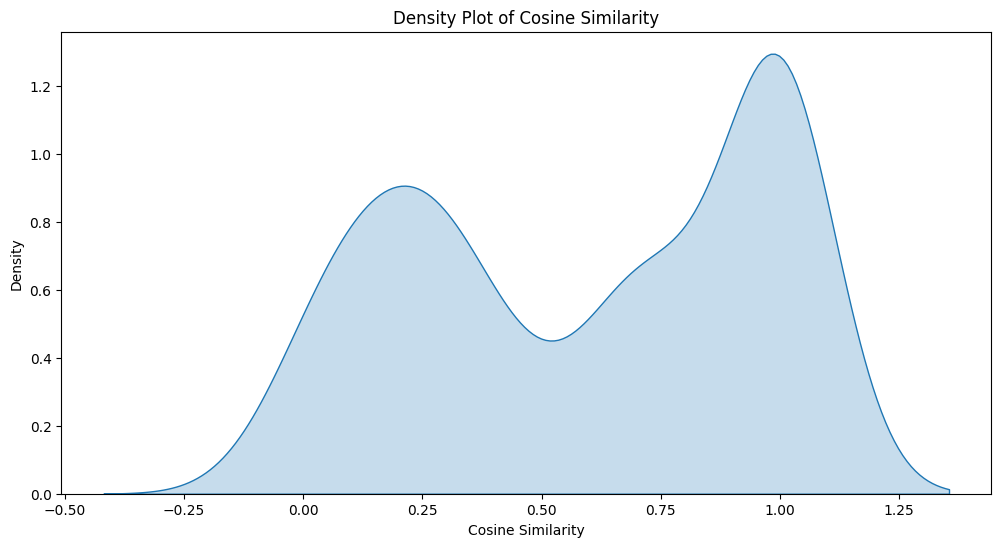

In [66]:
# show density plot and histogram of cosine similarity
plt.figure(figsize=(12, 6))
sns.kdeplot(df['cosine_similarity'].dropna(), fill=True)
plt.title('Density Plot of Cosine Similarity')
plt.xlabel('Cosine Similarity')
plt.ylabel('Density')
plt.show()